# Requirment 1 
Load the dataset and show the first ten rows.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import dash_bootstrap_components as dbc
import os
import threading
from flask import Flask, request, jsonify, render_template
from flask_cors import CORS
import statsmodels

In [2]:
CreditScore = pd.read_csv(r'CreditScore.csv', low_memory=False)

In [3]:
CreditScore.head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529544,High_spent_Small_value_payments,312.4940887,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.2802216,Low_spent_Large_value_payments,284.6291625,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.69952126,Low_spent_Medium_value_payments,331.2098629,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580744,Low_spent_Small_value_payments,223.4513097,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.42015309,High_spent_Medium_value_payments,341.489231,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.43017233,!@9#%8,340.4792118,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674,Low_spent_Small_value_payments,244.5653167,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.78521651,High_spent_Medium_value_payments,358.1241676,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.2918252,Low_spent_Small_value_payments,470.6906269,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123783,High_spent_Large_value_payments,484.5912143,Good


# Requirement 2
Describe the dataset.

In [4]:
CreditScore.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,99989.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.473372,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.447752,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633330,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


# Requirment 4 Part 1
Applying Some Preprocesssing Steps (Cleaning Data) Before Doing the next Requirement 2 Steps as cleaning is needed first.

In [5]:
#drop irrelevant identifiers
cols_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN']
CreditScore = CreditScore.drop(columns=cols_to_drop, errors='ignore')

# LIST OF COLUMNS TO FIX
# These columns contain '_' mixed with numbers
dirty_numeric_cols = [
    'Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 
    'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 
    'Monthly_Balance'
]

for col in dirty_numeric_cols:
    
    CreditScore[col] = CreditScore[col].astype(str).str.replace('_', '', regex=False) #Remove '_'
    CreditScore[col] = pd.to_numeric(CreditScore[col], errors='coerce') #Convert to numeric (now "23" becomes 23, not NaN)

print("Garbage characters removed.")

Garbage characters removed.


In [6]:
#List of columns that MUST be integers (No .0 decimals)
int_cols = [
    'Age',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Num_Credit_Inquiries',
]

# Convert them to nullable Integers ('Int64' handles NaNs and removes decimals)
for col in int_cols:

    CreditScore[col] = CreditScore[col].astype('Int64')

print('Converted Some Numerical Columns To Inegers')

Converted Some Numerical Columns To Inegers


## Requirment 2.A
The type of distribution of the data.

<Figure size 1000x500 with 0 Axes>

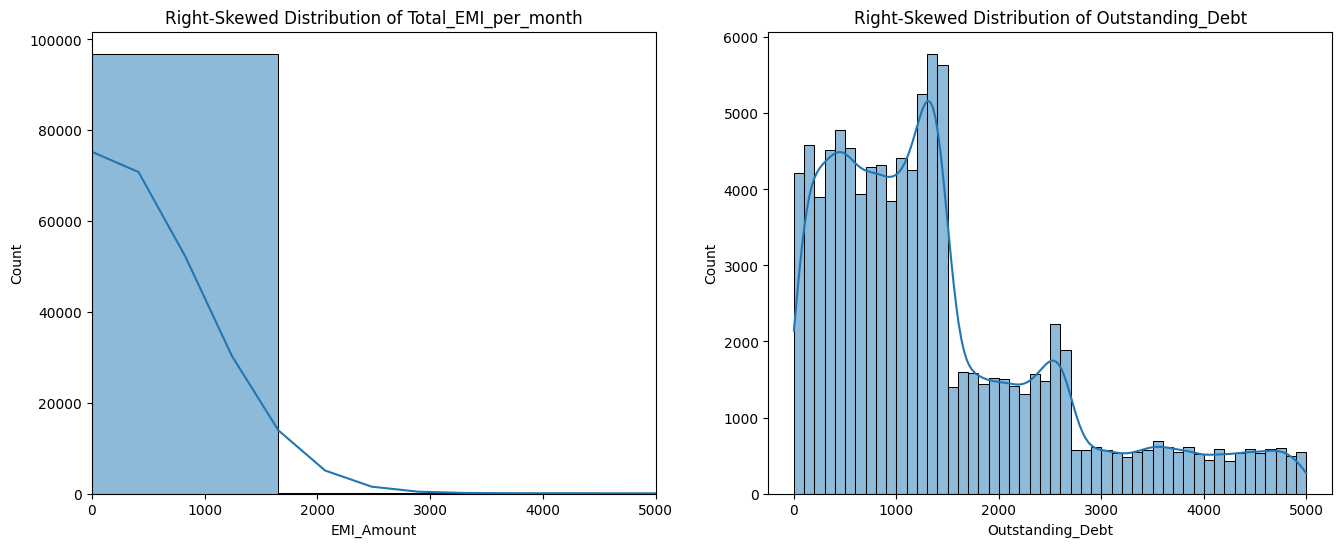

In [7]:
#lets pick Total_EMI_per_month as the example

col1 = 'Total_EMI_per_month'
col2 = 'Outstanding_Debt'

plt.figure(figsize=(10, 5))

#plot the distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(CreditScore[col1].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title(f'Right-Skewed Distribution of {col1}')
axes[0].set_xlim(0, 5000) #zoom in to see the main part
axes[0].set_xlabel('EMI_Amount')
sns.histplot(CreditScore[col2].dropna(), bins=50, kde=True, ax=axes[1])
axes[1].set_title(f'Right-Skewed Distribution of {col2}')
plt.show()

## Requirment 2.B 
If there are any outliers in the data, show them.

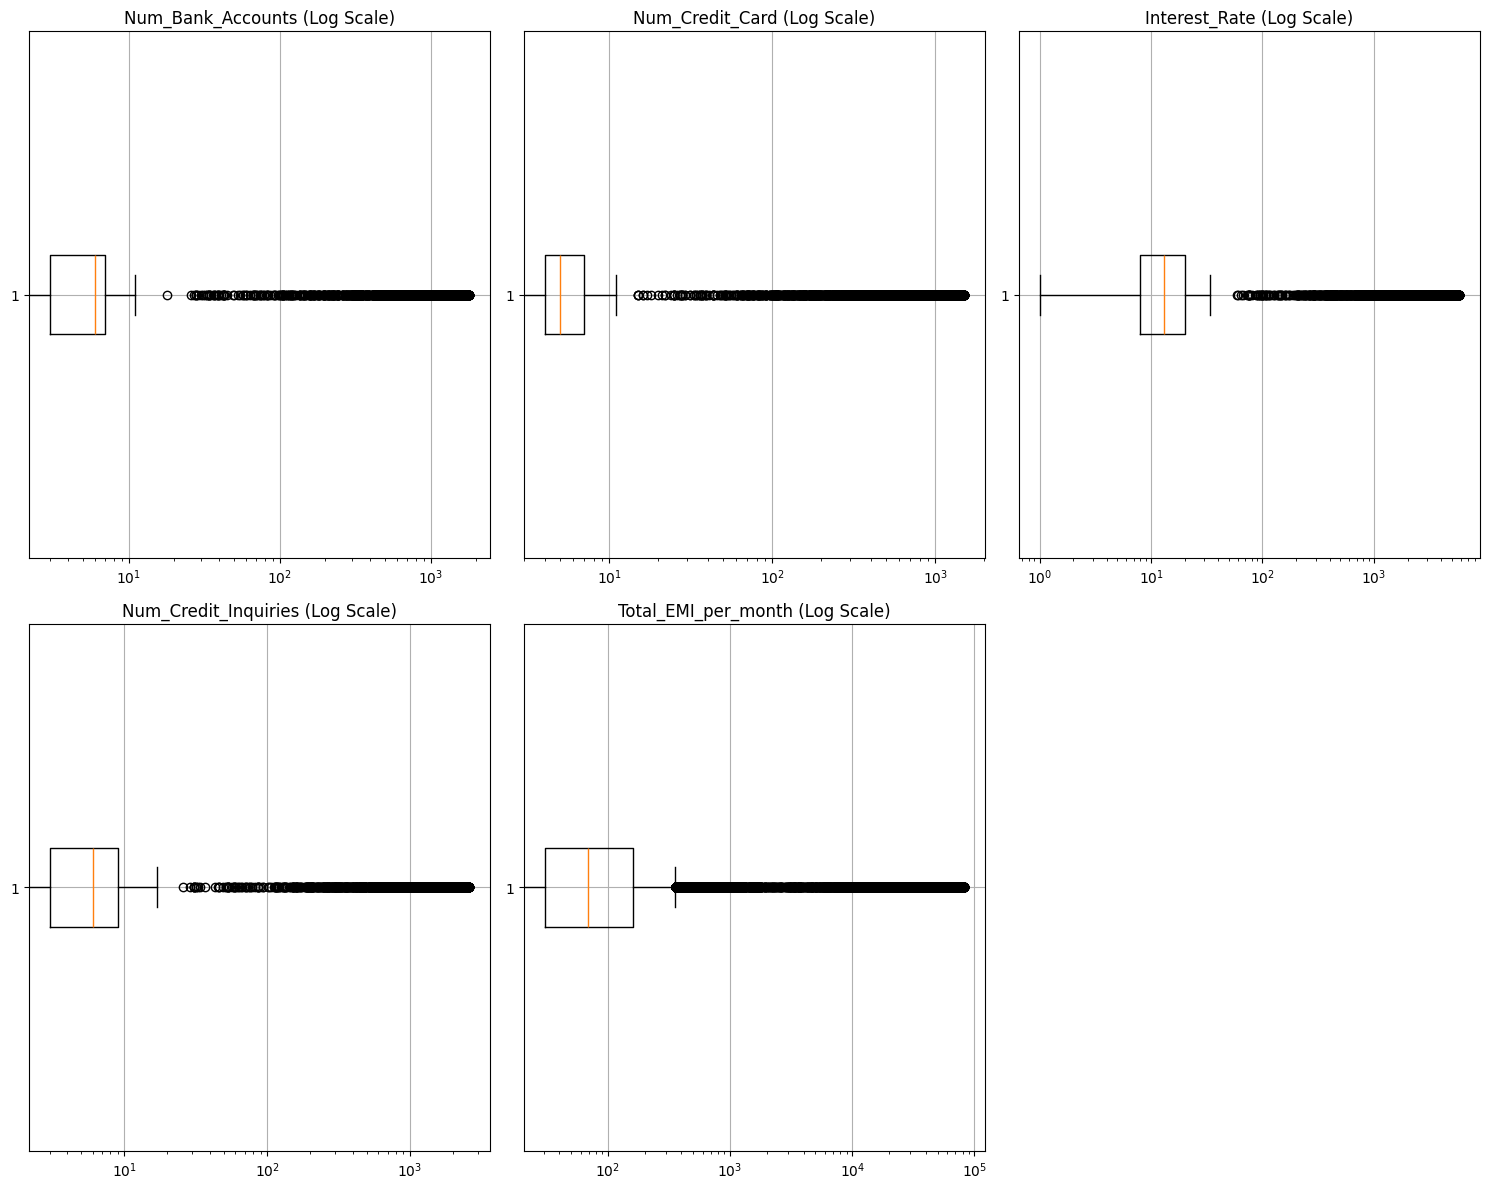

In [8]:
# define the columns you want to plot
columns = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_Credit_Inquiries', 'Total_EMI_per_month']

plt.figure(figsize=(15, 12))

for i, col in enumerate(columns, 1):
    
    plt.subplot(2, 3, i)
    plt.boxplot(CreditScore[col].dropna(), vert=False)
    plt.xscale('log')  #log scale to compresses the huge values so we can see both the box and the outliers.
    plt.title(f'{col} (Log Scale)')
    plt.grid(True)

plt.tight_layout()
plt.show()

## Requirement 2.C
Show the top three columns containing high variety in the number of categories in case of categorical features in the data; or the top three columns with the highest variance in case of all features were numeric.

In [9]:
print(CreditScore.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  object 
 1   Age                       99968 non-null   Int64  
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  Int64  
 6   Num_Credit_Card           100000 non-null  Int64  
 7   Interest_Rate             99989 non-null   float64
 8   Num_of_Loan               100000 non-null  Int64  
 9   Type_of_Loan              88592 non-null   object 
 10  Delay_from_due_date       100000 non-null  Int64  
 11  Num_of_Delayed_Payment    92998 non-null   Int64  
 12  Changed_Credit_Limit      97909 non-null   float64
 13  Num_Credit_Inquiries      98035 non-null   In

In [10]:
print("Requirment 2.C Before Dealing with outliers\n")
print("Top 3 Categorical Columns by Variety (Number of Unique Values)") #for categorical features

cat_cols = CreditScore.select_dtypes(include=['object', 'category']) #get only object/categorical columns

print(cat_cols.nunique().sort_values(ascending=False).head(3)) #count unique values and show top 3
print("\n" + "="*50 + "\n") #print new line
print("Top 3 Numeric Columns by Variance") #for numeric features

num_cols = CreditScore.select_dtypes(include=['number']) #get numeric columns

print(num_cols.var().sort_values(ascending=False).head(3)) #calculate variance and show top 3

Requirment 2.C Before Dealing with outliers

Top 3 Categorical Columns by Variety (Number of Unique Values)
Type_of_Loan          6260
Credit_History_Age     404
Occupation              16
dtype: int64


Top 3 Numeric Columns by Variance
Monthly_Balance        1012063793036964881291789186057238688433491987...
Annual_Income                                       2043807772929.203857
Total_EMI_per_month                                      68990321.584288
dtype: Float64


# Requirement 4 Part 2
Applying Some Preprocesssing Steps (Dealing with Outliers) Before Doing the next Requirement 2 Steps.

In [11]:
def parse_credit_history(val):
    
    if pd.isna(val): return np.nan
    val = str(val)
    # Check if the expected format "Years" and "Months" exists
    if "Years" in val and "Months" in val:
        try:
            parts = val.split(" Years and ")
            years = int(parts[0])
            months_part = parts[1].split(" Months")[0]
            months = int(months_part)
            return (years * 12) + months
        except:
            return np.nan
    return np.nan

CreditScore['Credit_History_Age_Months'] = CreditScore['Credit_History_Age'].apply(parse_credit_history)
# Drop the original text column
CreditScore = CreditScore.drop(columns=['Credit_History_Age'])

print("Credit History converted to Total Months.")

Credit History converted to Total Months.


In [12]:
# 1. Age: Replace negative values or >100 with the Median
median_age = CreditScore.loc[(CreditScore['Age'] > 0) & (CreditScore['Age'] < 100), 'Age'].median() #imputed with median because it doesnt get affected by outliers
CreditScore.loc[(CreditScore['Age'] < 0) | (CreditScore['Age'] > 100), 'Age'] = median_age

# 2. Num_of_Loan: Replace negative values with 0
CreditScore.loc[CreditScore['Num_of_Loan'] < 0, 'Num_of_Loan'] = 0

print("Outliers treated.")

Outliers treated.


In [13]:
#FIXING UNREASONABLE DATA

# 3. DELAYED PAYMENTS: Fix negatives and cap extreme outliers
CreditScore.loc[CreditScore['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = 0
# Cap at 30 (reasonable high number)
CreditScore.loc[CreditScore['Num_of_Delayed_Payment'] > 30, 'Num_of_Delayed_Payment'] = 30

# 4. INTEREST RATE: Cap at 35%
CreditScore.loc[CreditScore['Interest_Rate'] > 35, 'Interest_Rate'] = 35 #searched on google

# 5. CREDIT INQUIRIES: Cap at 20
CreditScore.loc[CreditScore['Num_Credit_Inquiries'] > 20, 'Num_Credit_Inquiries'] = 20 

# 6. OCCUPATION: Fix missing placeholder
CreditScore['Occupation'] = CreditScore['Occupation'].str.replace('_______', 'Other', regex=False)

# 7. PAYMENT BEHAVIOUR: Fix garbage string
mode_behavior = CreditScore['Payment_Behaviour'].mode()[0] #used mode because its categorical
CreditScore['Payment_Behaviour'] = CreditScore['Payment_Behaviour'].replace('!@9#%8', mode_behavior)

# 8. CREDIT MIX: Fix underscores
CreditScore['Credit_Mix'] = CreditScore['Credit_Mix'].replace('_', 'Standard')

# 9. ALL negatives are garbage errors, we set them to NaN
CreditScore.loc[CreditScore['Monthly_Balance'] < 0, 'Monthly_Balance'] = np.nan

print("All unreasonable rows have been fixed.")

All unreasonable rows have been fixed.


In [14]:
# Cap the outliers in Num_Credit_Card at a reasonable limit (e.g., 20)
# This assumes anyone with > 20 cards is an error, but we treat them as "High Number of Cards"
upper_limit = 20 
CreditScore['Num_Credit_Card'] = CreditScore['Num_Credit_Card'].apply(lambda x: upper_limit if x > upper_limit else x)

print("Outliers capped. Max value is now:", CreditScore['Num_Credit_Card'].max())

Outliers capped. Max value is now: 20


In [15]:
print("Requirment 2.C After Dealing with outliers\n")
print("Top 3 Categorical Columns by Variety (Number of Unique Values)") #for categorical features

cat_cols = CreditScore.select_dtypes(include=['object', 'category']) #get only object/categorical columns

print(cat_cols.nunique().sort_values(ascending=False).head(3)) #count unique values and show top 3
print("\n" + "="*50 + "\n") #print new line
print("Top 3 Numeric Columns by Variance") #for numeric features

num_cols = CreditScore.select_dtypes(include=['number']) #get numeric columns

print(num_cols.var().sort_values(ascending=False).head(3)) #calculate variance and show top 3

Requirment 2.C After Dealing with outliers

Top 3 Categorical Columns by Variety (Number of Unique Values)
Type_of_Loan    6260
Occupation        16
Month              8
dtype: int64


Top 3 Numeric Columns by Variance
Annual_Income            2043807772929.203857
Total_EMI_per_month           68990321.584288
Monthly_Inhand_Salary         10135857.609003
dtype: Float64


In [16]:
print("Unique before fix:", CreditScore['Payment_of_Min_Amount'].unique())

Unique before fix: ['No' 'NM' 'Yes']


In [17]:
CreditScore['Payment_of_Min_Amount'] = CreditScore['Payment_of_Min_Amount'].replace('NM', 'No')
CreditScore['Payment_of_Min_Amount'] = CreditScore['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})

print("Unique after fix:", CreditScore['Payment_of_Min_Amount'].unique())

Unique after fix: [0 1]


## Requirement 2.D
If there are any correlations between variables.

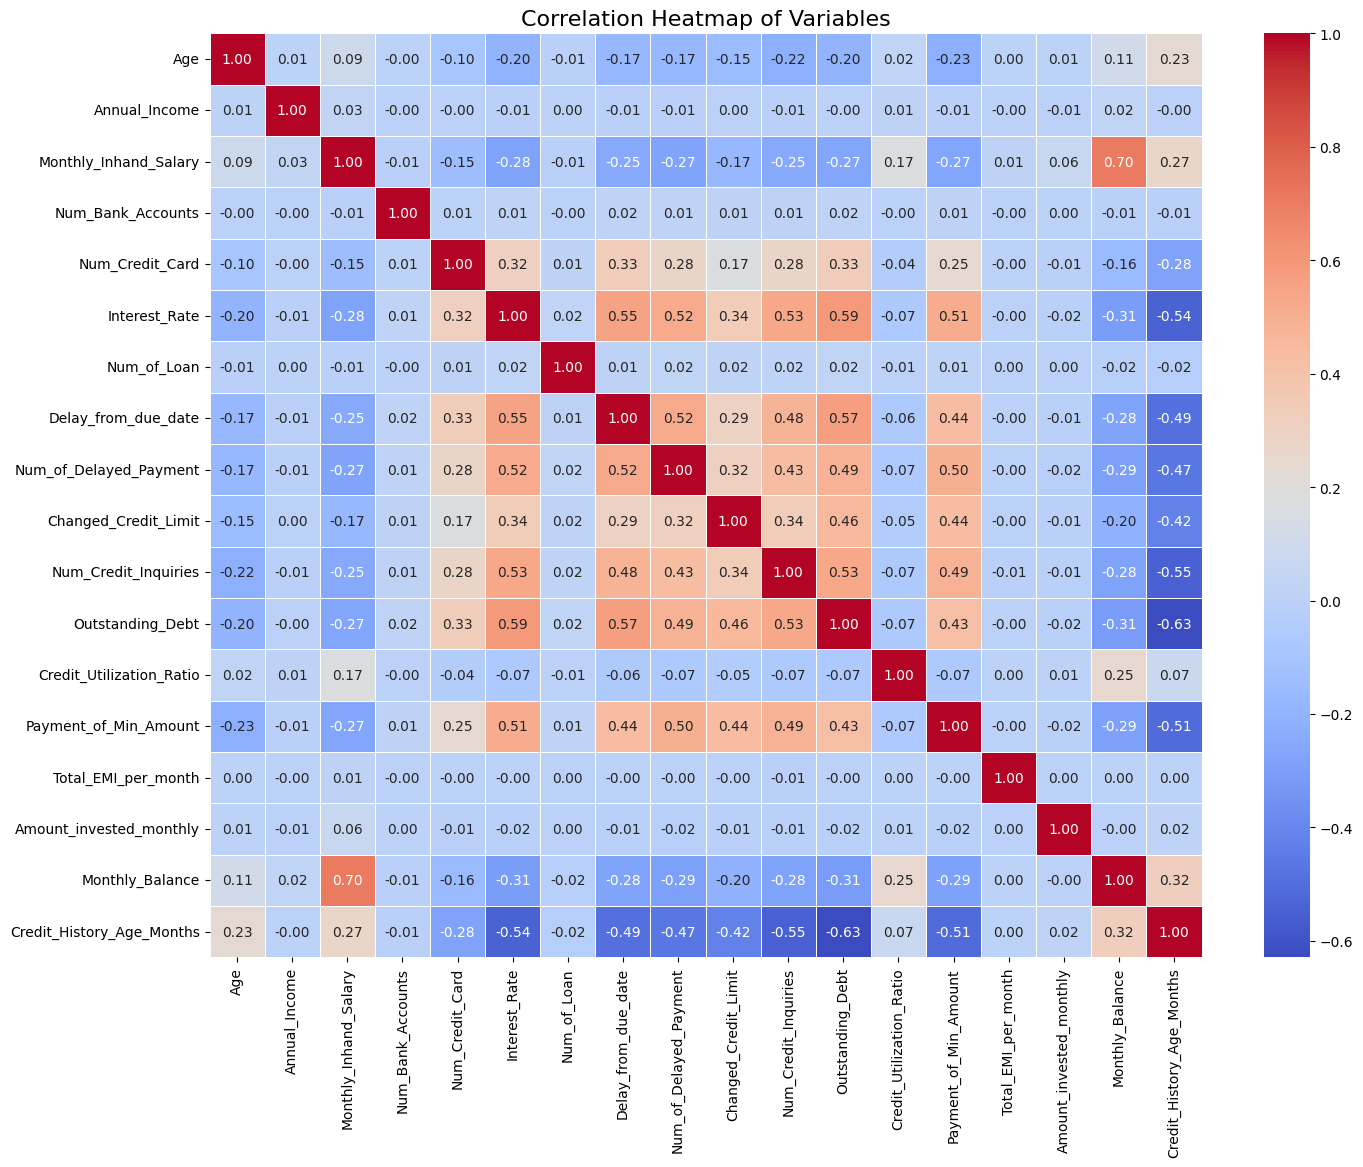

In [18]:
plt.figure(figsize=(16, 12)) #set the figure size (making it large enough to read the numbers)

corr_matrix = CreditScore.corr(numeric_only=True) #calculate the correlation matrix for numeric columns

#annot=True: Writes the number in each box
#fmt=".2f": Formats the numbers to 2 decimal places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Variables', fontsize=16)
plt.show()

# Requirement 3
Creating a meaningful interactive dashboard

In [49]:
# 1. Data Loading
try:
    
    df = CreditScore # Load the clean dataset directly

except Exception as e:
    
    print(f"Error loading file or variable 'CreditScore' not found: {e}")
    # Minimal fallback data to prevent crash during testing
    df = pd.DataFrame({
        'Credit_Score': ['Good', 'Standard', 'Poor'] * 10,
        'Occupation': ['Engineer', 'Doctor', 'Artist'] * 10,
        'Age': [25, 35, 45] * 10,
        'Annual_Income': [50000, 80000, 30000] * 10,
        'Outstanding_Debt': [1000, 500, 2000] * 10,
        'Interest_Rate': [15, 10, 20] * 10,
        'Num_of_Delayed_Payment': [1, 0, 5] * 10,
        'Total_EMI_per_month': [100, 200, 50] * 10,
        'Credit_Utilization_Ratio': [30, 10, 80] * 10
    })

# 2. App Setup
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.CERULEAN])

dropdown_options = [
    {'label': 'Annual Income', 'value': 'Annual_Income'},
    {'label': 'Outstanding Debt', 'value': 'Outstanding_Debt'},
    {'label': 'Interest Rate', 'value': 'Interest_Rate'},
    {'label': 'Num of Delayed Payments', 'value': 'Num_of_Delayed_Payment'},
    {'label': 'Total EMI per Month', 'value': 'Total_EMI_per_month'},
    {'label': 'Credit Utilization Ratio', 'value': 'Credit_Utilization_Ratio'}
]


# 3. Layout
app.layout = dbc.Container([
    
    html.H1("Credit Score Analysis Dashboard", className="text-center my-4"),
    html.Hr(), # creates a horizontal line to seperate
    
    # Dropdown Row
    dbc.Row([
        dbc.Col([
            html.Label("Select Metric to Analyze:", className="fw-bold"),
            dcc.Dropdown(
                id='metric-dropdown',
                options=dropdown_options,
                value='Outstanding_Debt', #default value
                clearable=False
            )
        ], width=6)
    ], className="mb-4"),
    
    # Charts Row 1: Box Plot & Regression
    dbc.Row([
        # Box Plot: Great for seeing if "Poor" scores always have higher debt
        dbc.Col([dcc.Graph(id='box-plot')], width=6),
        
        dbc.Col([dcc.Graph(id='line-plot')], width=6)
    ], className="mb-4"),

    # Charts Row 2: Bar Chart
    dbc.Row([
        # Bar Plot: Compares occupations
        dbc.Col([dcc.Graph(id='bar-plot')], width=12)
    ])

], fluid=True)

# 4. Callback

@app.callback(
    [Output('box-plot', 'figure'),
     Output('line-plot', 'figure'),
     Output('bar-plot', 'figure')],
    [Input('metric-dropdown', 'value')]
)
def update_charts(selected_metric):
    
    # Chart 1: Box Plot (Distribution)
    fig1 = px.box(
        df, x='Credit_Score', y=selected_metric, color='Credit_Score',
        title=f"Distribution of {selected_metric} by Score",
        template="plotly_white",
        # Force specific order so 'Good' is always first/last as you prefer
        category_orders={"Credit_Score": ["Good", "Standard", "Poor"]},
        log_y=True  #log scaling to cap outliers
    )
    
    # Chart 2:Line Chart of Averages

    # 1. Group by Age and calculate the mean of the selected metric
    line_df = df.groupby('Age')[selected_metric].mean().reset_index()

    # 2. Plot the line
    fig2 = px.line(
        line_df, 
        x='Age', 
        y=selected_metric, 
        title=f"Trend: Average {selected_metric} by Age",
        template="plotly_white",
        markers=True # Adds dots to the line for clarity
    )

    # Chart 3: Bar Chart (Aggregation)
    # Group by Occupation to get the mean
    avg_df = df.groupby('Occupation')[selected_metric].mean().reset_index()
    fig3 = px.bar(
        avg_df, x='Occupation', y=selected_metric, color='Occupation',
        title=f"Average {selected_metric} by Occupation",
        template="plotly_white"
    )
    
    return fig1, fig2, fig3


# 5. Run Server

if __name__ == '__main__':
    
    app.run(debug=True, port=8051)

# Requirment 4 Part 3
Applying Some Preprocesssing Steps (Imputation, Scaling, Encoding, Resampling, ...).

In [43]:
# Numeric Columns -> Fill with Median
numeric_cols = CreditScore.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    CreditScore[col] = CreditScore[col].fillna(CreditScore[col].median()) #better for outliers

# Categorical Columns -> Fill with Mode (Most Frequent)
# Also fix 'Credit_Mix' if it has garbage values like '_'
CreditScore['Credit_Mix'] = CreditScore['Credit_Mix'].replace('_', np.nan) 

categorical_cols = CreditScore.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if not CreditScore[col].mode().empty:
        CreditScore[col] = CreditScore[col].fillna(CreditScore[col].mode()[0])

print("Missing values imputed.")

Missing values imputed.


In [22]:
CreditScore.to_csv("CreditScoreForSQL.csv", index=False)

print("Data saved successfully for SQL import.")

Data saved successfully for SQL import.


In [20]:
CreditScore.drop(['Month'], axis =1, inplace = True)

In [23]:
#Encoding

CreditScore_encoded = CreditScore.copy() #Create Copy

#Manual Mapping (Ordinal)
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
CreditScore_encoded['Credit_Mix'] = CreditScore_encoded['Credit_Mix'].map(credit_mix_map).fillna(1)

target_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
CreditScore_encoded['Credit_Score'] = CreditScore_encoded['Credit_Score'].map(target_map)

#Label Encoding (for Payment_Behaviour)
le = LabelEncoder()
CreditScore_encoded['Payment_Behaviour'] = le.fit_transform(CreditScore_encoded['Payment_Behaviour'].astype(str))

#Dummy Encoding
cols_to_dummy = ['Occupation']

#Create the encoded columns separately
encoded_categories = pd.get_dummies(CreditScore_encoded[cols_to_dummy], prefix='Occupation', drop_first=True)

#Drop the original Nominal columns from df_encoded
CreditScore_encoded.drop(columns=cols_to_dummy, axis=1, inplace=True)

#Concatenate them together
CreditScore_encoded = pd.concat([CreditScore_encoded, encoded_categories], axis=1)

#Remove messy column
if 'Type_of_Loan' in CreditScore_encoded.columns:
    
    CreditScore_encoded = CreditScore_encoded.drop(columns=['Type_of_Loan'])

print("Encoding Complete. Shape:", CreditScore_encoded.shape)

Encoding Complete. Shape: (100000, 36)


In [24]:
#Scaling

CreditScore_scaled = CreditScore_encoded.copy()
scaler = RobustScaler() #better with outliers as it uses IQR

#Select continuous columns (exclude Target and Binary columns like Payment_of_Min_Amount)
continuous_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 
    'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months'
]
cols_to_scale = [c for c in continuous_cols if c in CreditScore_scaled.columns] # Only scale columns that exist

CreditScore_scaled[cols_to_scale] = scaler.fit_transform(CreditScore_scaled[cols_to_scale])

print("Scaling Complete.")
print(CreditScore_scaled[['Payment_of_Min_Amount', 'Age', 'Credit_Score']].head())

Scaling Complete.
   Payment_of_Min_Amount    Age  Credit_Score
0                      0 -0.625             2
1                      0 -0.625             2
2                      0  0.000             2
3                      0 -0.625             2
4                      0 -0.625             2


# Requirment 5, 6 and 7
Building and Evaluating a machine learning model and using to predict upcoming rows

In [25]:
final_CreditScore = CreditScore_scaled.copy()

final_CreditScore.to_csv("preprocessed_dataset.csv", index=False)

In [26]:
final_CreditScore['Credit_Score'].value_counts()

Credit_Score
1    53174
0    28998
2    17828
Name: count, dtype: int64

In [27]:
def train_creditScore_Model(trainingData):

    # features X and Target y
    # drop the Target column from X, only the Target in y
    X = trainingData.drop(columns=['Credit_Score']) 
    y = trainingData['Credit_Score']

    # split the Data
    # 80% training model, 20% testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Data successfully split!")
    print(f"Training shape: {X_train.shape}")
    print(f"Testing shape: {X_test.shape}")

    # n_estimators=100 means we are building 100 decision Trees
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

    # train the Model
    print("Training the model... this might take a few seconds.")
    rf_model.fit(X_train, y_train)

    print("Model trained successfully!")

    # let the Model predict the credit scores for the test data
    y_pred = rf_model.predict(X_test)

    # accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy: {accuracy:.2%}")
    print("-" * 30)

    # report (Precision, Recall, F1)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

    #precision is the true number of right classification of predicted output
    #recall 
    #f1 balance performance of the precision and recall

    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # save the Model
    joblib.dump(rf_model, 'credit_score_model.pkl')
    print("\nModel saved successfully as 'credit_score_model.pkl'")

    # Save the scaler so we can use it for new predictions
    joblib.dump(scaler, 'scaler.pkl')
    print("Scaler saved successfully!")

In [28]:
train_creditScore_Model(final_CreditScore)

Data successfully split!
Training shape: (80000, 35)
Testing shape: (20000, 35)
Training the model... this might take a few seconds.
Model trained successfully!
Model Accuracy: 78.38%
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      5874
           1       0.80      0.81      0.80     10599
           2       0.74      0.69      0.71      3527

    accuracy                           0.78     20000
   macro avg       0.77      0.76      0.77     20000
weighted avg       0.78      0.78      0.78     20000

------------------------------
Confusion Matrix:
[[4636 1120  118]
 [1240 8603  756]
 [  20 1070 2437]]

Model saved successfully as 'credit_score_model.pkl'
Scaler saved successfully!


In [29]:
def predict_credit_score(new_data_dictionary):
    # takes Dictionary of new customer data, preprocesses it,and predicts Credit Score.
    
    # load saved Model and scaler
    model = joblib.load('credit_score_model.pkl')
    scaler = joblib.load('scaler.pkl')

    # Convert the dictionary into a data frame (one row)
    input_df = pd.DataFrame([new_data_dictionary])

    # preprocessing  
    # clean characters ('_') in numeric columns
    cols_to_clean = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 
                     'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 
                     'Monthly_Balance']
    
    for col in cols_to_clean:
        if col in input_df.columns:
            input_df[col] = input_df[col].astype(str).str.replace('_', '', regex=False)
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce').fillna(0)

    # mapping Ordinal variables
    credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
    if 'Credit_Mix' in input_df.columns:
        input_df['Credit_Mix'] = input_df['Credit_Mix'].map(credit_mix_map).fillna(1)
        
    if 'Payment_of_Min_Amount' in input_df.columns:
        input_df['Payment_of_Min_Amount'] = input_df['Payment_of_Min_Amount'].apply(lambda x: 1 if x == 'Yes' else 0)

    #dummy encoding
    input_df = pd.get_dummies(input_df)
    # get the list of columns the model was trained on
    model_columns = model.feature_names_in_
    
    # must input df have these exact columns. 
    # if column is missing, adds it with value 0.
    input_df = input_df.reindex(columns=model_columns, fill_value=0)

    # scale continous variables
    continuous_cols = [
        'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
        'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
        'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 
        'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 
        'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months'
    ]
    
    # only scale columns that exist in our aligned dataframe
    cols_to_scale = [c for c in continuous_cols if c in input_df.columns]
    input_df[cols_to_scale] = scaler.transform(input_df[cols_to_scale])

    # predict
    prediction_index = model.predict(input_df)[0]
    
    # map back to readable string
    classes = {0: "Poor", 1: "Standard", 2: "Good"} 
    result = classes.get(prediction_index, "Unknown")
    
    return result

In [30]:
# testing the Function
new_customer = {
    'Age': '35',
    'Annual_Income': '90000',
    'Monthly_Inhand_Salary': 7000,
    'Num_Bank_Accounts': 3,
    'Num_Credit_Card': 4,
    'Interest_Rate': 15,
    'Num_of_Loan': '2',
    'Delay_from_due_date': 5,
    'Num_of_Delayed_Payment': '4_',
    'Changed_Credit_Limit': 10.5,
    'Num_Credit_Inquiries': 2,
    'Credit_Mix': 'Good',
    'Outstanding_Debt': 1500,
    'Credit_Utilization_Ratio': 35,
    'Credit_History_Age_Months': 200,
    'Payment_of_Min_Amount': 'No',
    'Total_EMI_per_month': 100,
    'Amount_invested_monthly': 200,
    'Payment_Behaviour': 'High_spent_Small_value_payments',
    'Monthly_Balance': 400
}

# call the Function
predicted_score = predict_credit_score(new_customer)
print(f"The predicted Credit Score for this new customer is: {predicted_score}")

The predicted Credit Score for this new customer is: Standard


In [31]:
# testing the Function
new_customer2 = {
    'Age': '45',                       
    'Annual_Income': '150000.0',        
    'Monthly_Inhand_Salary': 12000,     
    'Num_Bank_Accounts': 2,             
    'Num_Credit_Card': 3,            
    'Interest_Rate': 5,              
    'Num_of_Loan': '1',               
    'Delay_from_due_date': 0,           
    'Num_of_Delayed_Payment': '0',      
    'Changed_Credit_Limit': 5.0,       
    'Num_Credit_Inquiries': 0,         
    'Credit_Mix': 'Good',               
    'Outstanding_Debt': 100.0,          
    'Credit_Utilization_Ratio': 15,     
    'Credit_History_Age_Months': 300,   
    'Payment_of_Min_Amount': 'No',      
    'Total_EMI_per_month': 50,          
    'Amount_invested_monthly': 1000.0,  
    'Payment_Behaviour': 'Low_spent_Small_value_payments', 
    'Monthly_Balance': 800.0,           
    'Occupation': 'Scientist'           
}

prediction = predict_credit_score(new_customer2)
print(f"Prediction for this customer: {prediction}")

Prediction for this customer: Good


# Bonus

In [40]:
# ==============================================================================
# 1. DEFINE SAFE DEFAULTS
# ==============================================================================
SAFE_DEFAULTS = {
    "Age": 35, "Annual_Income": 80000.0, "Monthly_Inhand_Salary": 7000.0,
    "Num_Bank_Accounts": 2, "Num_Credit_Card": 3, "Interest_Rate": 8,
    "Num_of_Loan": 1, "Delay_from_due_date": 5, "Num_of_Delayed_Payment": 2,
    "Changed_Credit_Limit": 15.0, "Num_Credit_Inquiries": 1, "Credit_Mix": "Good",
    "Outstanding_Debt": 500.0, "Credit_Utilization_Ratio": 25,
    "Credit_History_Age_Months": 250, "Payment_of_Min_Amount": "No",
    "Total_EMI_per_month": 50.0, "Amount_invested_monthly": 200.0,
    "Payment_Behaviour": "High_spent_Medium_value_payments", "Monthly_Balance": 600.0,
    "Occupation": "Engineer", "Type_of_Loan": "Auto Loan"
}


# 2. GENERATE HTML (Train Button + Predict Form)

html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>Credit Score System</title>
    <meta charset="UTF-8">
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background: #f0f2f5; padding: 20px; }
        .container { background: white; max-width: 900px; margin: 0 auto; padding: 30px; border-radius: 10px; box-shadow: 0 4px 10px rgba(0,0,0,0.1); }
        h1 { text-align: center; color: #2c3e50; }
        
        /* Admin Section Styles */
        .admin-panel { background: #f8f9fa; padding: 20px; border-radius: 8px; border: 1px solid #ddd; margin-bottom: 30px; text-align: center; }
        .btn-train { background: #34495e; color: white; padding: 12px 30px; border: none; border-radius: 5px; cursor: pointer; font-size: 1.1em; }
        .btn-train:hover { background: #2c3e50; }
        #train-status { margin-top: 10px; font-weight: bold; color: #555; }

        /* Grid & Input Styles */
        .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 15px; }
        label { font-weight: bold; font-size: 0.9em; display: block; margin-bottom: 5px; color: #34495e; }
        input, select { width: 100%; padding: 8px; border: 1px solid #ccc; border-radius: 4px; box-sizing: border-box; }
        
        /* Predict Button Styles */
        .btn-predict { width: 100%; padding: 15px; background: #3498db; color: white; border: none; border-radius: 5px; font-size: 1.2em; cursor: pointer; margin-top: 20px; transition: background 0.3s; }
        .btn-predict:hover { background: #2980b9; }
        
        /* Result Styles */
        #result { margin-top: 20px; padding: 20px; text-align: center; font-weight: bold; font-size: 2em; border-radius: 8px; }
        .Good { background-color: #2ecc71; color: white; }
        .Standard { background-color: #f1c40f; color: black; }
        .Poor { background-color: #e74c3c; color: white; }
    </style>
</head>
<body>
<div class="container">
    <h1> Credit Score Analysis System</h1>

    <div class="admin-panel">
        <button class="btn-train" onclick="trainModel()"> Train Model</button>
        <div id="train-status"></div>
    </div>

    <h3> Predict New Customer</h3>
    <div class="grid">
        <div><label>Age</label><input type="number" id="Age" value="45"></div>
        <div><label>Occupation</label><input type="text" id="Occupation" value="Scientist"></div>
        
        <div><label>Annual Income ($)</label><input type="number" id="Annual_Income" value="150000"></div>
        <div><label>Monthly In-hand Salary ($)</label><input type="number" id="Monthly_Inhand_Salary" value="12000"></div>
        <div><label>Num Bank Accounts</label><input type="number" id="Num_Bank_Accounts" value="2"></div>
        <div><label>Num Credit Cards</label><input type="number" id="Num_Credit_Card" value="3"></div>

        <div><label>Interest Rate (%)</label><input type="number" id="Interest_Rate" value="5"></div>
        <div><label>Num of Loans</label><input type="number" id="Num_of_Loan" value="1"></div>
        <div><label>Type of Loan</label><input type="text" id="Type_of_Loan" value="Auto Loan"></div>
        
        <div><label>Delay from Due Date (days)</label><input type="number" id="Delay_from_due_date" value="0"></div>
        <div><label>Num Delayed Payments</label><input type="number" id="Num_of_Delayed_Payment" value="0"></div>
        <div><label>Changed Credit Limit</label><input type="number" id="Changed_Credit_Limit" value="5.0"></div>
        <div><label>Num Credit Inquiries</label><input type="number" id="Num_Credit_Inquiries" value="0"></div>
        <div><label>Credit Mix</label>
            <select id="Credit_Mix"><option value="Good" selected>Good</option><option value="Standard">Standard</option><option value="Bad">Bad</option></select>
        </div>

        <div><label>Outstanding Debt ($)</label><input type="number" id="Outstanding_Debt" value="100.0"></div>
        <div><label>Credit Utilization Ratio (%)</label><input type="number" id="Credit_Utilization_Ratio" value="15"></div>
        <div><label>Credit History Age (Months)</label><input type="number" id="Credit_History_Age_Months" value="300"></div>
        
        <div><label>Payment of Min Amount</label>
            <select id="Payment_of_Min_Amount"><option value="No" selected>No</option><option value="Yes">Yes</option></select>
        </div>
        <div><label>Payment Behaviour</label>
            <select id="Payment_Behaviour">
                <option value="Low_spent_Small_value_payments" selected>Low Spent - Small Value</option>
                <option value="High_spent_Medium_value_payments">High Spent - Medium Value</option>
                <option value="Low_spent_Large_value_payments">Low Spent - Large Value</option>
                <option value="High_spent_Small_value_payments">High Spent - Small Value</option>
            </select>
        </div>

        <div><label>Total EMI per Month ($)</label><input type="number" id="Total_EMI_per_month" value="50"></div>
        <div><label>Amount Invested Monthly ($)</label><input type="number" id="Amount_invested_monthly" value="1000"></div>
        <div><label>Monthly Balance ($)</label><input type="number" id="Monthly_Balance" value="800"></div>
    </div>

    <button class="btn-predict" onclick="predict()"> Predict Credit Score</button>
    <div id="result"></div>
</div>

<script>
    // --- FUNCTION 1: TRAIN MODEL ---
    async function trainModel() {
        const statusDiv = document.getElementById('train-status');
        statusDiv.innerText = "Training in progress... Please wait...";
        statusDiv.style.color = "blue";

        try {
            const response = await fetch('http://127.0.0.1:5008/train', { method: 'POST' });
            const result = await response.json();

            if (result.status === 'success') {
                statusDiv.innerText = result.message;
                statusDiv.style.color = "green";
            } else {
                statusDiv.innerText = "Error: " + result.message;
                statusDiv.style.color = "red";
            }
        } catch (e) {
            statusDiv.innerText = "Connection Error: " + e;
            statusDiv.style.color = "red";
        }
    }

    // --- FUNCTION 2: PREDICT ---
    async function predict() {
        const data = {
            Age: document.getElementById('Age').value,
            Occupation: document.getElementById('Occupation').value,
            Annual_Income: document.getElementById('Annual_Income').value,
            Monthly_Inhand_Salary: document.getElementById('Monthly_Inhand_Salary').value,
            Num_Bank_Accounts: document.getElementById('Num_Bank_Accounts').value,
            Num_Credit_Card: document.getElementById('Num_Credit_Card').value,
            Interest_Rate: document.getElementById('Interest_Rate').value,
            Num_of_Loan: document.getElementById('Num_of_Loan').value,
            Type_of_Loan: document.getElementById('Type_of_Loan').value,
            Delay_from_due_date: document.getElementById('Delay_from_due_date').value,
            Num_of_Delayed_Payment: document.getElementById('Num_of_Delayed_Payment').value,
            Changed_Credit_Limit: document.getElementById('Changed_Credit_Limit').value,
            Num_Credit_Inquiries: document.getElementById('Num_Credit_Inquiries').value,
            Credit_Mix: document.getElementById('Credit_Mix').value,
            Outstanding_Debt: document.getElementById('Outstanding_Debt').value,
            Credit_Utilization_Ratio: document.getElementById('Credit_Utilization_Ratio').value,
            Credit_History_Age_Months: document.getElementById('Credit_History_Age_Months').value,
            Payment_of_Min_Amount: document.getElementById('Payment_of_Min_Amount').value,
            Payment_Behaviour: document.getElementById('Payment_Behaviour').value,
            Total_EMI_per_month: document.getElementById('Total_EMI_per_month').value,
            Amount_invested_monthly: document.getElementById('Amount_invested_monthly').value,
            Monthly_Balance: document.getElementById('Monthly_Balance').value
        };

        try {
            const response = await fetch('http://127.0.0.1:5008/predict', {
                method: 'POST',
                headers: { 'Content-Type': 'application/json' },
                body: JSON.stringify(data)
            });
            const result = await response.json();
            
            const div = document.getElementById('result');
            if (result.status === 'success') {
                div.innerText = result.prediction;
                div.className = result.prediction;
            } else {
                div.innerText = "Error: " + result.message;
                div.className = "Poor";
            }
        } catch (e) {
            alert("Error connecting to server: " + e);
        }
    }
</script>
</body>
</html>
"""

#Save HTML
if not os.path.exists('templates'):
    os.makedirs('templates')
with open('templates/index.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

# 3. FLASK SERVER (Port 5008)

app = Flask(__name__)
CORS(app)

@app.route('/')
def home():
    return render_template('index.html')

# --- ROUTE 1: TRAIN ---
@app.route('/train', methods=['POST'])
def train_route():
    try:
        
        train_creditScore_Model(final_CreditScore) 
        
        return jsonify({'status': 'success', 'message': 'Model Trained & Saved Successfully!'})
    except Exception as e:
        return jsonify({'status': 'error', 'message': str(e)})

# --- ROUTE 2: PREDICT ---
@app.route('/predict', methods=['POST'])
def predict_route():
    try:
        user_input = request.json
        
        # 1. Start with defaults (safety)
        final_data = SAFE_DEFAULTS.copy()
        
        # 2. Overwrite with user input
        final_data.update(user_input)
        
        # 3. Call your existing prediction function
        result = predict_credit_score(final_data)
        
        return jsonify({'status': 'success', 'prediction': result})
    except Exception as e:
        return jsonify({'status': 'error', 'message': str(e)})

def run_app():
    # Using Port 5008 to ensure a fresh connection
    app.run(port=5008, debug=False, use_reloader=False)

threading.Thread(target=run_app).start()
print("App Started! Go to: http://127.0.0.1:5008")

✅ App Started! Go to: http://127.0.0.1:5008
 * Serving Flask app '__main__'
 * Debug mode: off
